# 07 - Linear Regression, Perceptron, and Linear Separability

This notebook extends EnergyTypeNet with four foundational algorithms implemented in `src.models`: batch-gradient-descent linear regression, normal-equation linear regression, Rosenblatt Perceptron, and Adaline.

Dataset strategy:

- **EnergyTypeNet is the primary dataset** for regression, binary classification, and model comparison.
- **Synthetic sklearn datasets** are used only where a clean 2D geometry demonstration is necessary.
- No extra CSV files are added to the repository.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_blobs, make_classification, make_circles, make_moons
from sklearn.linear_model import LinearRegression, Perceptron as SklearnPerceptron
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models import (
    AdalineGD,
    LinearRegressionGD,
    LinearRegressionNormal,
    LogisticRegressionOvR,
    Perceptron,
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42

## 1. Linear Separability - Theory and Geometry

A dataset is **linearly separable** if there exists a hyperplane that assigns every training point to the correct class. In two dimensions, that hyperplane is just a line. The Rosenblatt Perceptron convergence theorem guarantees that the Perceptron will find a separating hyperplane in a finite number of updates **only when the data is linearly separable**.

When the classes overlap, form XOR-style structure, curve into moons, or form concentric circles, no single straight line can perfectly separate the classes. In those cases, the Perceptron may keep updating forever because each new line still misclassifies some points.

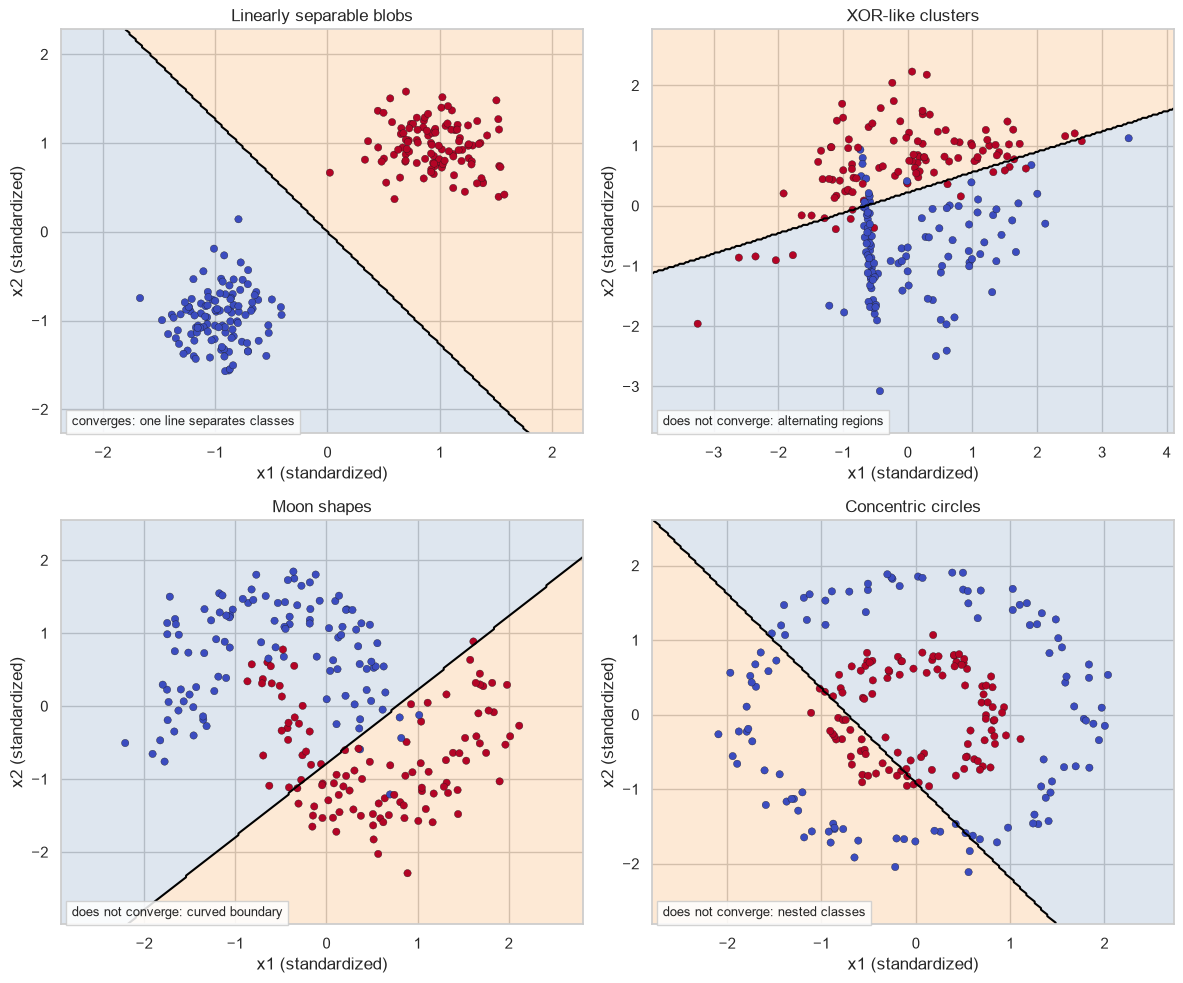

In [2]:
def plot_linear_boundary(ax, model, X):
    x_min, x_max = X[:, 0].min() - 0.7, X[:, 0].max() + 0.7
    y_min, y_max = X[:, 1].min() - 0.7, X[:, 1].max() + 0.7
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 250),
        np.linspace(y_min, y_max, 250),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.18, levels=[-0.5, 0.5, 1.5], colors=['#4C78A8', '#F58518'])
    ax.contour(xx, yy, zz, levels=[0.5], colors='black', linewidths=1.5)


def plot_dataset(ax, X, y, title, note):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    model = Perceptron(learning_rate=1.0, n_iterations=40).fit(X_scaled, y)

    plot_linear_boundary(ax, model, X_scaled)
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='coolwarm', s=28, edgecolor='k', linewidth=0.25)
    ax.set_title(title)
    ax.set_xlabel('x1 (standardized)')
    ax.set_ylabel('x2 (standardized)')
    ax.text(
        0.02,
        0.02,
        note,
        transform=ax.transAxes,
        fontsize=9,
        bbox={'facecolor': 'white', 'alpha': 0.85, 'edgecolor': '#cccccc'},
    )

X_blob, y_blob = make_blobs(n_samples=220, centers=[[-2, -2], [2, 2]], cluster_std=0.6, random_state=RANDOM_STATE)
X_xor, y_xor = make_classification(
    n_samples=220,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=2,
    class_sep=0.8,
    random_state=RANDOM_STATE,
)
X_moons_small, y_moons_small = make_moons(n_samples=220, noise=0.2, random_state=RANDOM_STATE)
X_circles, y_circles = make_circles(n_samples=220, noise=0.08, factor=0.45, random_state=RANDOM_STATE)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plot_dataset(axes[0, 0], X_blob, y_blob, 'Linearly separable blobs', 'converges: one line separates classes')
plot_dataset(axes[0, 1], X_xor, y_xor, 'XOR-like clusters', 'does not converge: alternating regions')
plot_dataset(axes[1, 0], X_moons_small, y_moons_small, 'Moon shapes', 'does not converge: curved boundary')
plot_dataset(axes[1, 1], X_circles, y_circles, 'Concentric circles', 'does not converge: nested classes')
plt.tight_layout()
plt.show()

## 2. LinearRegressionGD vs LinearRegressionNormal on EnergyTypeNet

Here EnergyTypeNet is used as a regression dataset. The target is `Energy Consumption`, and the predictors are `Square Footage`, `Number of Occupants`, `Appliances Used`, and `Average Temperature`.

The custom gradient-descent model learns by iterative optimization, while the normal-equation model solves the least-squares system directly. sklearn's `LinearRegression` is included as a reference implementation.

In [3]:
train_df = pd.read_csv(PROJECT_ROOT / 'data' / 'train_energy_data.csv').dropna()
test_df = pd.read_csv(PROJECT_ROOT / 'data' / 'test_energy_data.csv').dropna()

reg_features = [
    'Square Footage',
    'Number of Occupants',
    'Appliances Used',
    'Average Temperature',
]
reg_target = 'Energy Consumption'

X_train_reg = train_df[reg_features].astype(float).values
X_test_reg = test_df[reg_features].astype(float).values
y_train_reg = train_df[reg_target].astype(float).values
y_test_reg = test_df[reg_target].astype(float).values

reg_scaler = StandardScaler()
X_train_reg_scaled = reg_scaler.fit_transform(X_train_reg)
X_test_reg_scaled = reg_scaler.transform(X_test_reg)

reg_models = {
    'LinearRegressionGD': LinearRegressionGD(learning_rate=0.05, n_iterations=1500),
    'LinearRegressionNormal': LinearRegressionNormal(),
    'sklearn LinearRegression': LinearRegression(),
}

reg_results = []
reg_predictions = {}

for name, model in reg_models.items():
    model.fit(X_train_reg_scaled, y_train_reg)
    train_pred = model.predict(X_train_reg_scaled)
    test_pred = model.predict(X_test_reg_scaled)
    reg_predictions[name] = test_pred

    reg_results.append({
        'model': name,
        'train_mse': mean_squared_error(y_train_reg, train_pred),
        'test_mse': mean_squared_error(y_test_reg, test_pred),
        'train_mae': mean_absolute_error(y_train_reg, train_pred),
        'test_mae': mean_absolute_error(y_test_reg, test_pred),
        'train_r2': r2_score(y_train_reg, train_pred),
        'test_r2': r2_score(y_test_reg, test_pred),
    })

reg_summary = pd.DataFrame(reg_results).sort_values('test_mse')
reg_summary

,model,train_mse,test_mse,train_mae,test_mae,train_r2,test_r2
0,LinearRegressionGD,165639.573145,184783.489834,339.857004,374.231081,0.809654,0.730724
2,sklearn LinearRegression,165639.573145,184783.489834,339.857004,374.231081,0.809654,0.730724
1,LinearRegressionNormal,165639.573145,184783.489834,339.857004,374.231081,0.809654,0.730724


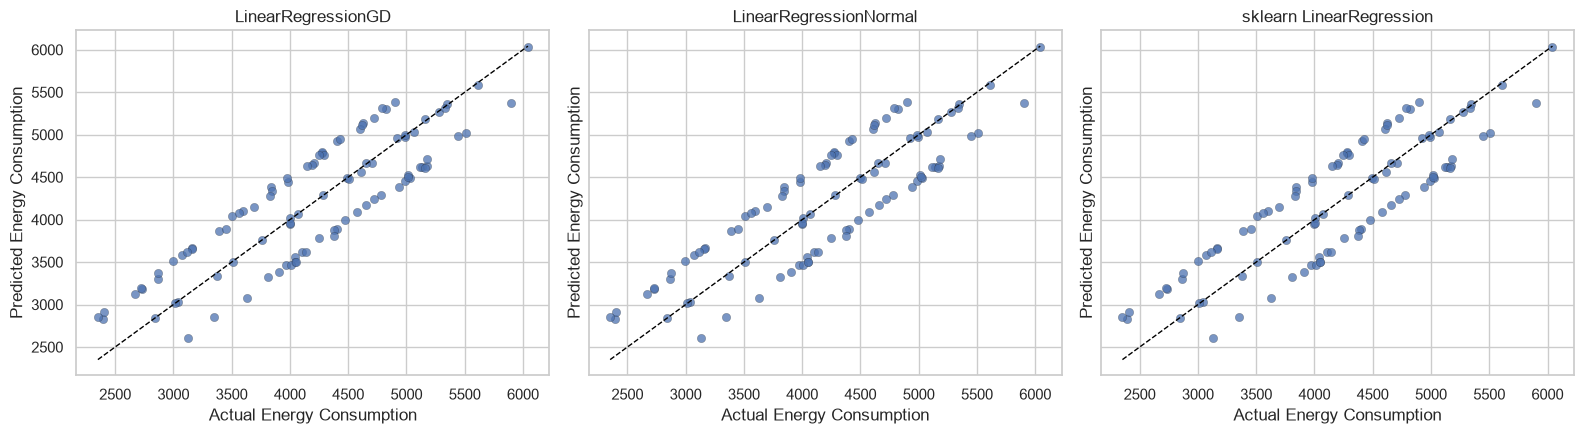

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True, sharey=True)

for ax, (name, pred) in zip(axes, reg_predictions.items()):
    ax.scatter(y_test_reg, pred, alpha=0.75, edgecolor='k', linewidth=0.2)
    lo = min(y_test_reg.min(), pred.min())
    hi = max(y_test_reg.max(), pred.max())
    ax.plot([lo, hi], [lo, hi], color='black', linestyle='--', linewidth=1)
    ax.set_title(name)
    ax.set_xlabel('Actual Energy Consumption')
    ax.set_ylabel('Predicted Energy Consumption')

plt.tight_layout()
plt.show()

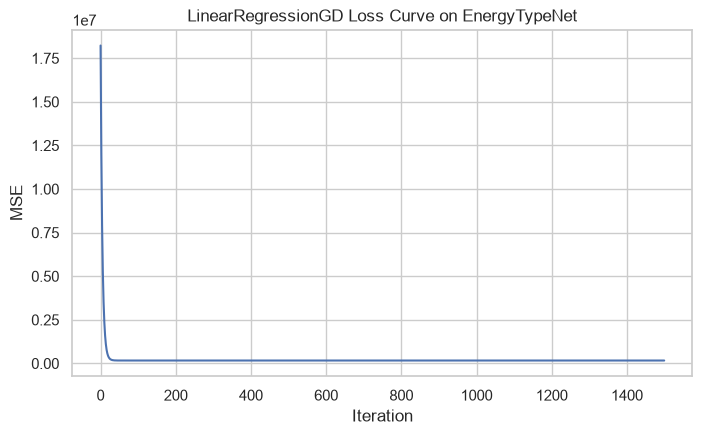

In [5]:
gd_model = reg_models['LinearRegressionGD']

plt.figure(figsize=(8, 4.5))
plt.plot(gd_model.loss_history_)
plt.title('LinearRegressionGD Loss Curve on EnergyTypeNet')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.show()

## 3. Learning Rate Sensitivity on EnergyTypeNet

Gradient descent depends heavily on the learning rate. A learning rate that is too small converges slowly. A learning rate that is too large can overshoot the minimum and cause the loss to oscillate or diverge.

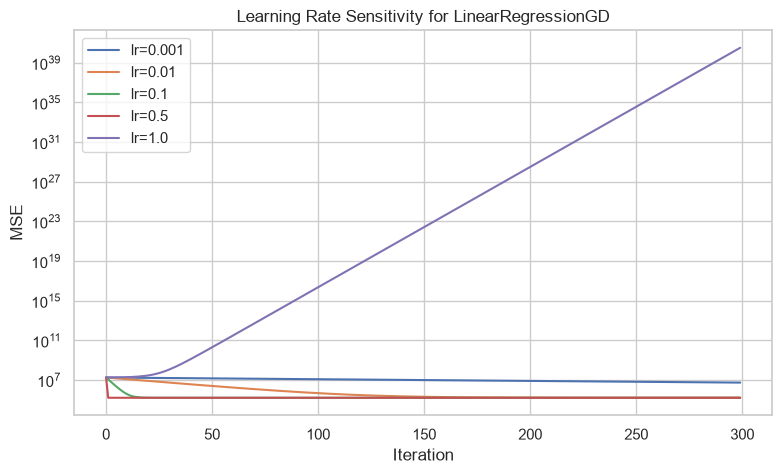

,learning_rate,initial_loss,final_loss,status
0,0.001,1.822786e+07,5.616487e+06,converged/improved
1,0.010,1.822786e+07,1.657414e+05,converged/improved
2,0.100,1.822786e+07,1.656396e+05,converged/improved
3,0.500,1.822786e+07,1.656396e+05,converged/improved
4,1.000,1.822786e+07,3.263294e+40,diverged


In [6]:
learning_rates = [0.001, 0.01, 0.1, 0.5, 1.0]
lr_histories = {}
lr_status = []

for lr in learning_rates:
    model = LinearRegressionGD(learning_rate=lr, n_iterations=300)
    model.fit(X_train_reg_scaled, y_train_reg)
    history = np.array(model.loss_history_)
    lr_histories[lr] = history

    finite = np.all(np.isfinite(history))
    improved = finite and history[-1] < history[0]
    diverged = (not finite) or history[-1] > history[0] * 10

    lr_status.append({
        'learning_rate': lr,
        'initial_loss': history[0],
        'final_loss': history[-1],
        'status': 'diverged' if diverged else ('converged/improved' if improved else 'unstable/slow'),
    })

plt.figure(figsize=(9, 5))
for lr, history in lr_histories.items():
    clipped = np.where(np.isfinite(history), history, np.nan)
    plt.plot(clipped, label=f'lr={lr}')

plt.title('Learning Rate Sensitivity for LinearRegressionGD')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.yscale('log')
plt.legend()
plt.show()

pd.DataFrame(lr_status)

## 4. Perceptron on EnergyTypeNet Binary Classification

The multiclass EnergyTypeNet target is converted into a binary task: **Residential = 1** and **Commercial/Industrial = 0**. This tests whether a linear classifier can separate Residential buildings from all others.

In [7]:
binary_features = [
    'Energy Consumption',
    'Square Footage',
    'Number of Occupants',
    'Appliances Used',
    'Average Temperature',
]

X_train_bin = train_df[binary_features].astype(float).values
X_test_bin = test_df[binary_features].astype(float).values
y_train_bin = (train_df['Building Type'] == 'Residential').astype(int).values
y_test_bin = (test_df['Building Type'] == 'Residential').astype(int).values

bin_scaler = StandardScaler()
X_train_bin_scaled = bin_scaler.fit_transform(X_train_bin)
X_test_bin_scaled = bin_scaler.transform(X_test_bin)

custom_perceptron = Perceptron(learning_rate=1.0, n_iterations=50).fit(X_train_bin_scaled, y_train_bin)
custom_adaline = AdalineGD(learning_rate=0.01, n_iterations=80).fit(X_train_bin_scaled, y_train_bin)
sklearn_perceptron = SklearnPerceptron(max_iter=1000, tol=1e-3, random_state=RANDOM_STATE).fit(X_train_bin_scaled, y_train_bin)

perceptron_results = pd.DataFrame([
    {
        'model': 'Custom Perceptron',
        'train_accuracy': accuracy_score(y_train_bin, custom_perceptron.predict(X_train_bin_scaled)),
        'test_accuracy': accuracy_score(y_test_bin, custom_perceptron.predict(X_test_bin_scaled)),
        'final_epoch_errors': custom_perceptron.errors_[-1],
    },
    {
        'model': 'Custom AdalineGD',
        'train_accuracy': accuracy_score(y_train_bin, custom_adaline.predict(X_train_bin_scaled)),
        'test_accuracy': accuracy_score(y_test_bin, custom_adaline.predict(X_test_bin_scaled)),
        'final_epoch_errors': np.nan,
    },
    {
        'model': 'sklearn Perceptron',
        'train_accuracy': accuracy_score(y_train_bin, sklearn_perceptron.predict(X_train_bin_scaled)),
        'test_accuracy': accuracy_score(y_test_bin, sklearn_perceptron.predict(X_test_bin_scaled)),
        'final_epoch_errors': np.nan,
    },
])
perceptron_results

,model,train_accuracy,test_accuracy,final_epoch_errors
0,Custom Perceptron,1.000,1.0,0.0
1,Custom AdalineGD,0.653,0.6,NaN
2,sklearn Perceptron,1.000,1.0,NaN


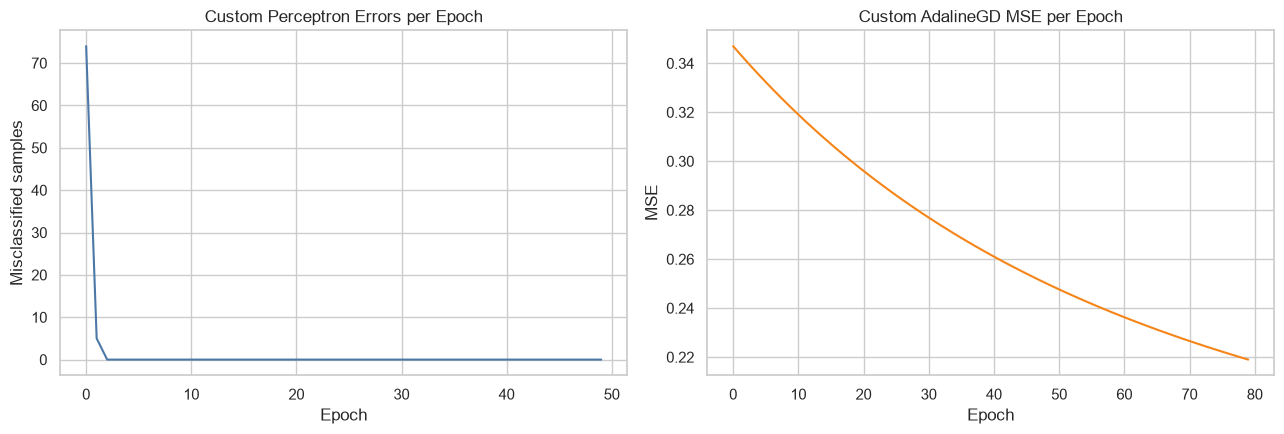

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(custom_perceptron.errors_, color='#4C78A8')
axes[0].set_title('Custom Perceptron Errors per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Misclassified samples')

axes[1].plot(custom_adaline.loss_history_, color='#F58518')
axes[1].set_title('Custom AdalineGD MSE per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE')

plt.tight_layout()
plt.show()

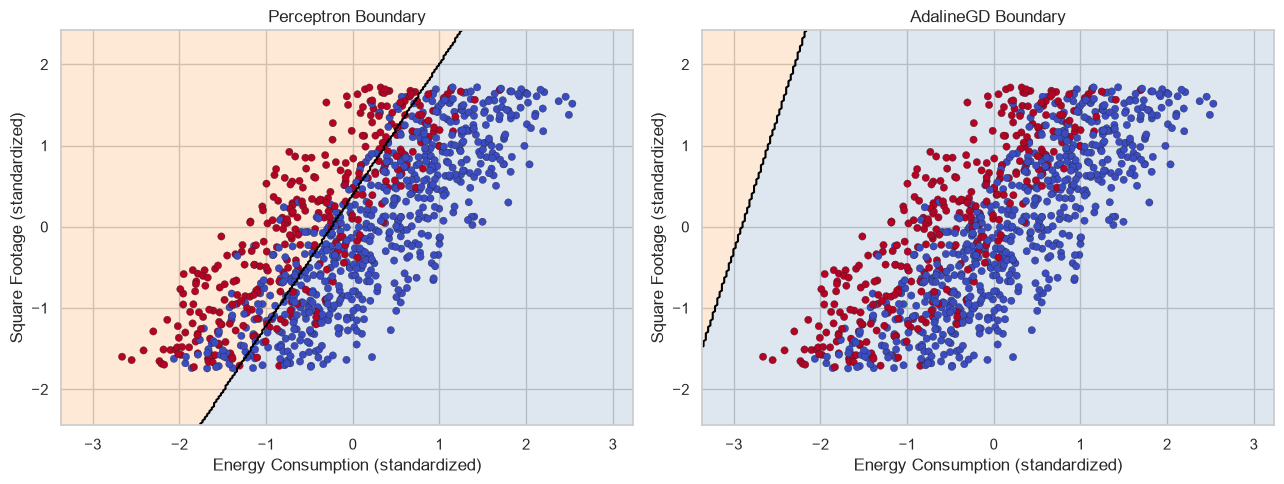

In [9]:
def plot_2d_boundary(ax, model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.7, X[:, 0].max() + 0.7
    y_min, y_max = X[:, 1].min() - 0.7, X[:, 1].max() + 0.7
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 250),
        np.linspace(y_min, y_max, 250),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.18, levels=[-0.5, 0.5, 1.5], colors=['#4C78A8', '#F58518'])
    ax.contour(xx, yy, zz, levels=[0.5], colors='black', linewidths=1.5)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=28, edgecolor='k', linewidth=0.2)
    ax.set_title(title)
    ax.set_xlabel('Energy Consumption (standardized)')
    ax.set_ylabel('Square Footage (standardized)')

plot_features_2d = ['Energy Consumption', 'Square Footage']
X_train_2d = train_df[plot_features_2d].astype(float).values
scaler_2d = StandardScaler()
X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)

perceptron_2d = Perceptron(learning_rate=1.0, n_iterations=50).fit(X_train_2d_scaled, y_train_bin)
adaline_2d = AdalineGD(learning_rate=0.01, n_iterations=80).fit(X_train_2d_scaled, y_train_bin)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_2d_boundary(axes[0], perceptron_2d, X_train_2d_scaled, y_train_bin, 'Perceptron Boundary')
plot_2d_boundary(axes[1], adaline_2d, X_train_2d_scaled, y_train_bin, 'AdalineGD Boundary')
plt.tight_layout()
plt.show()

**Observation:** The Residential-vs-rest task is much easier than the original 3-class building-type problem. A perfect Perceptron score here means this binary split is close to linearly separable under the selected features; it should not be interpreted as evidence that the full multiclass EnergyTypeNet task is solved.


## 5. Perceptron Failure on Non-Linear Data

EnergyTypeNet is high-dimensional and multiclass, so a 2D toy dataset is used here only to show the geometry of a non-linear boundary. The moon-shaped dataset cannot be perfectly separated by one straight line.

In [10]:
X_moon, y_moon = make_moons(n_samples=500, noise=0.2, random_state=RANDOM_STATE)
moon_scaler = StandardScaler()
X_moon_scaled = moon_scaler.fit_transform(X_moon)

moon_perceptron = Perceptron(learning_rate=1.0, n_iterations=60).fit(X_moon_scaled, y_moon)
moon_logistic = LogisticRegressionOvR(eta=0.01, n_iter=1500, alpha=0.001, random_state=RANDOM_STATE).fit(X_moon_scaled, y_moon)

moon_results = pd.DataFrame([
    {
        'model': 'Custom Perceptron',
        'accuracy': accuracy_score(y_moon, moon_perceptron.predict(X_moon_scaled)),
        'final_epoch_errors': moon_perceptron.errors_[-1],
    },
    {
        'model': 'Custom LogisticRegressionOvR',
        'accuracy': accuracy_score(y_moon, moon_logistic.predict(X_moon_scaled)),
        'final_epoch_errors': np.nan,
    },
])
moon_results

,model,accuracy,final_epoch_errors
0,Custom Perceptron,0.802,84.0
1,Custom LogisticRegressionOvR,0.860,NaN


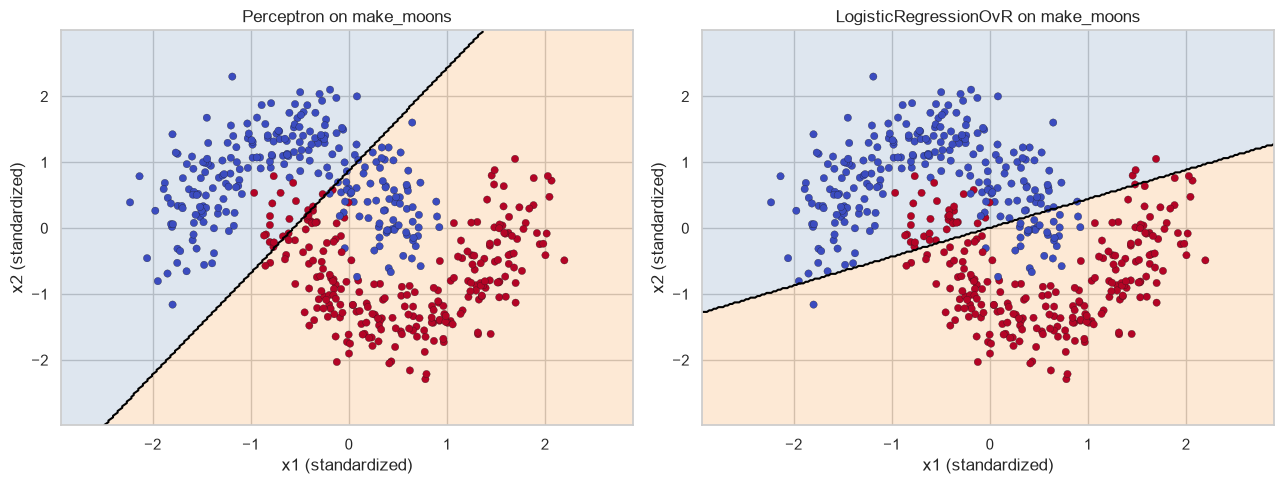

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_2d_boundary(axes[0], moon_perceptron, X_moon_scaled, y_moon, 'Perceptron on make_moons')
plot_2d_boundary(axes[1], moon_logistic, X_moon_scaled, y_moon, 'LogisticRegressionOvR on make_moons')
axes[0].set_xlabel('x1 (standardized)')
axes[0].set_ylabel('x2 (standardized)')
axes[1].set_xlabel('x1 (standardized)')
axes[1].set_ylabel('x2 (standardized)')
plt.tight_layout()
plt.show()

The Perceptron uses hard threshold updates and depends on linear separability for guaranteed convergence. Logistic regression also learns a linear boundary in the original feature space, but it models class probabilities and optimizes a smooth loss. That makes it more stable on overlapping data, even though a plain linear logistic model still cannot perfectly represent the curved moon boundary.

## 6. Summary Table

In [12]:
summary_rows = [
    {
        'Algorithm': 'LinearRegressionGD',
        'Dataset': 'EnergyTypeNet',
        'Task': 'Energy Consumption regression',
        'Custom?': 'Yes',
        'Train metric': f"R2={reg_summary.loc[reg_summary['model'] == 'LinearRegressionGD', 'train_r2'].iloc[0]:.3f}",
        'Test metric': f"R2={reg_summary.loc[reg_summary['model'] == 'LinearRegressionGD', 'test_r2'].iloc[0]:.3f}",
        'Notes': 'Learns by iterative gradient descent; learning rate matters.',
    },
    {
        'Algorithm': 'LinearRegressionNormal',
        'Dataset': 'EnergyTypeNet',
        'Task': 'Energy Consumption regression',
        'Custom?': 'Yes',
        'Train metric': f"R2={reg_summary.loc[reg_summary['model'] == 'LinearRegressionNormal', 'train_r2'].iloc[0]:.3f}",
        'Test metric': f"R2={reg_summary.loc[reg_summary['model'] == 'LinearRegressionNormal', 'test_r2'].iloc[0]:.3f}",
        'Notes': 'Solves least squares directly with lstsq fallback.',
    },
    {
        'Algorithm': 'sklearn LinearRegression',
        'Dataset': 'EnergyTypeNet',
        'Task': 'Energy Consumption regression',
        'Custom?': 'No',
        'Train metric': f"R2={reg_summary.loc[reg_summary['model'] == 'sklearn LinearRegression', 'train_r2'].iloc[0]:.3f}",
        'Test metric': f"R2={reg_summary.loc[reg_summary['model'] == 'sklearn LinearRegression', 'test_r2'].iloc[0]:.3f}",
        'Notes': 'Reference implementation.',
    },
    {
        'Algorithm': 'Perceptron',
        'Dataset': 'EnergyTypeNet',
        'Task': 'Residential vs rest',
        'Custom?': 'Yes',
        'Train metric': f"acc={perceptron_results.loc[0, 'train_accuracy']:.3f}",
        'Test metric': f"acc={perceptron_results.loc[0, 'test_accuracy']:.3f}",
        'Notes': 'Convergence depends on linear separability.',
    },
    {
        'Algorithm': 'AdalineGD',
        'Dataset': 'EnergyTypeNet',
        'Task': 'Residential vs rest',
        'Custom?': 'Yes',
        'Train metric': f"acc={perceptron_results.loc[1, 'train_accuracy']:.3f}",
        'Test metric': f"acc={perceptron_results.loc[1, 'test_accuracy']:.3f}",
        'Notes': 'Optimizes continuous linear activation before thresholding.',
    },
    {
        'Algorithm': 'Perceptron',
        'Dataset': 'make_moons',
        'Task': 'Non-linear binary classification',
        'Custom?': 'Yes',
        'Train metric': f"acc={moon_results.loc[0, 'accuracy']:.3f}",
        'Test metric': 'same in-memory demo',
        'Notes': 'Shows failure mode on non-linearly separable geometry.',
    },
]

summary_table = pd.DataFrame(summary_rows)
summary_table

,Algorithm,Dataset,Task,Custom?,Train metric,Test metric,Notes
0,LinearRegressionGD,EnergyTypeNet,Energy Consumption regression,Yes,R2=0.810,R2=0.731,Learns by iterative gradient descent; learning...
1,LinearRegressionNormal,EnergyTypeNet,Energy Consumption regression,Yes,R2=0.810,R2=0.731,Solves least squares directly with lstsq fallb...
2,sklearn LinearRegression,EnergyTypeNet,Energy Consumption regression,No,R2=0.810,R2=0.731,Reference implementation.
3,Perceptron,EnergyTypeNet,Residential vs rest,Yes,acc=1.000,acc=1.000,Convergence depends on linear separability.
4,AdalineGD,EnergyTypeNet,Residential vs rest,Yes,acc=0.653,acc=0.600,Optimizes continuous linear activation before ...
5,Perceptron,make_moons,Non-linear binary classification,Yes,acc=0.802,same in-memory demo,Shows failure mode on non-linearly separable g...


### Key Takeaways

- Linear regression can be implemented either as an optimization problem or a closed-form least-squares problem.
- Batch gradient descent is sensitive to feature scale and learning rate, which is why EnergyTypeNet features are standardized first.
- The Perceptron is simple and interpretable, but its convergence guarantee applies only to linearly separable data.
- The binary Residential-vs-rest experiment is intentionally easier than the full 3-class task, so its high accuracy is a separability demonstration rather than the main benchmark.
- Adaline uses a continuous training signal, so its learning curve is smoother than the Perceptron's epoch-level error count.
- EnergyTypeNet can support both regression and binary classification experiments, but toy 2D datasets are still useful for explaining geometry that real tabular data cannot show cleanly.
